# TASK: inverse kinematics

You are provided with a dataset of shape (1000, 10), where each row represents a single datapoint. Each datapoint contains:

(1) The first 3 dimensions: robot end-effector position (x, y, z)

(2) The last 7 dimensions: corresponding robot joint angles (7-DOF robot arm)

Answer the following three questions:

Q1. Given a new end-effector position x = -0.17014326, y = -0.11960592, z = 1.74256186, find the K nearest end-effector positions from the dataset using Euclidean distance.

Q2. Use the K-nearest neighbors (KNN) method to predict the corresponding joint angles for the new end-effector position by averaging the joint angles of the K nearest neighbors found in step 1.

Q3. The ground-truth joint angles for the query end-effector position are [-0.34353379, -0.09202018, 0.52489392, -0.74799594, -0.60716157, 0.90288965, -0.64901675]. Sweep K over a range of values (K = 1, 2, ..., 20). For each value of K, compute the prediction error (i.e, Euclidean distance between two vectors) between the KNN-predicted joint angles and the ground-truth joint angles, then plots the K–error figure with labelled axes, markers, and a grid.

In [23]:
import numpy as np
import matplotlib.pyplot as plt

The dataset includes 1000 samples/datapoints


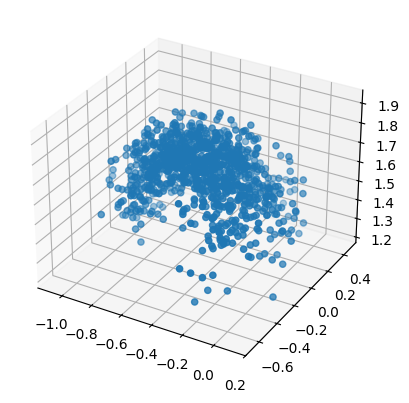

In [24]:
data = np.load("data.npy")
eef_position = data[..., 0:3]   # x, y, z coordinates
joint_angles = data[..., 3:]    # joint angles for a seven degree of freedom robot
K = 20  # Use this value for Q1-Q2 (you will sweep K from 1 to 20 in Q3)
print("The dataset includes {} samples/datapoints".format(len(data)))

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(eef_position[:, 0], eef_position[:, 1], eef_position[:, 2])
plt.show()

The indices of the K nearest neighbors are: [279 507 297 317 656 701 588 804 310 128 113 622 664 202 144 586  17 504
 369 592]
Predicted joint angles: [ 0.01579421  0.23246316  0.00412925 -0.32332557  0.00476661  0.42469335
  0.02295059]


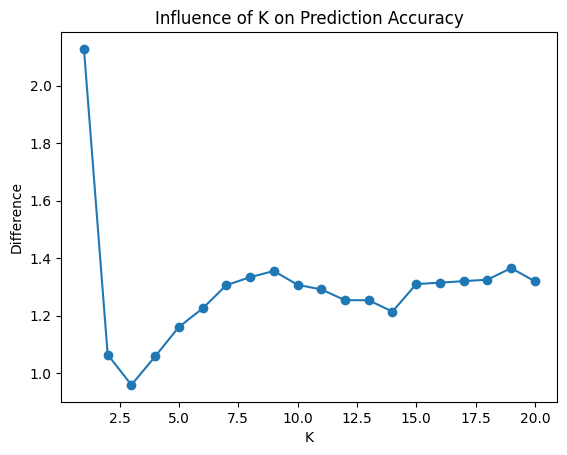

In [25]:
new_eef_pos = np.array([-0.17014326, -0.11960592, 1.74256186])
gt_joint_angles = np.array([
    -0.34353379, -0.09202018, 0.52489392, -0.74799594,
    -0.60716157, 0.90288965, -0.64901675
])
def euclidean_distance(pos1, pos2):
    return np.linalg.norm(pos1 - pos2)

def find_k_nearest_neighbors(eef_position, new_eef_pos, K):
    distances = np.array([euclidean_distance(pos, new_eef_pos) for pos in eef_position])
    nearest_indices = np.argsort(distances)[:K]
    return nearest_indices

def predict_joint_angles_knn(joint_angles, nearest_indices):
    return np.mean(joint_angles[nearest_indices], axis=0)

K = 20
nearest_indices = find_k_nearest_neighbors(eef_position, new_eef_pos, K)
print("The indices of the K nearest neighbors are:", nearest_indices)

pred_joint_angles = predict_joint_angles_knn(joint_angles, nearest_indices)
print("Predicted joint angles:", pred_joint_angles)

# plot the difference between the predicted joint angles and the actual joint angles of the nearest neighbor as K varies from 1 to 20

K_values = range(1, 21)
differences = []
for K in K_values:
    nearest_indices = find_k_nearest_neighbors(eef_position, new_eef_pos, K)
    pred_joint_angles = predict_joint_angles_knn(joint_angles, nearest_indices)
    difference = euclidean_distance(pred_joint_angles, gt_joint_angles)  # Example difference calculation
    differences.append(difference)


plt.plot(K_values, differences, marker='o')
plt.xlabel('K')
plt.ylabel('Difference')
plt.title('Influence of K on Prediction Accuracy')
plt.show()



# Report

Discuss how the choice of K affects prediction accuracy, and explain the trade-offs that arise when K is too small or too large.

Note: You are not asked to write code for this section. Instead, provide your analysis/discussion in your report.